<a href="https://colab.research.google.com/github/HarleenKaurBhullar/CustomerChurn/blob/main/CustomerChurnLR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

In [2]:
ccdata=pd.read_csv('/content/Bank Customer Churn Prediction.csv')

In [3]:
ccdata

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,15606229,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,15569892,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,15584532,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,15682355,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [4]:
ccdata.describe()

,customer_id,credit_score,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


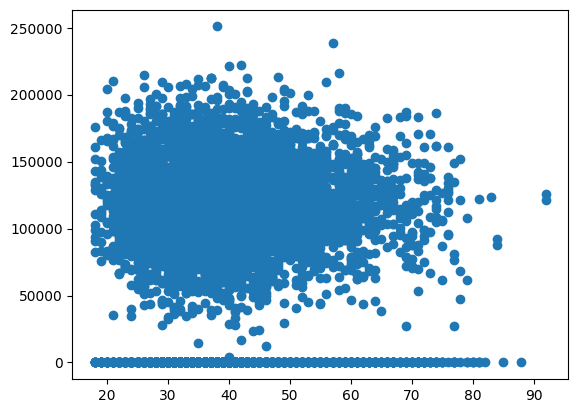

In [5]:
plt.scatter(ccdata['age'],ccdata['balance'])

<Axes: xlabel='age', ylabel='balance'>

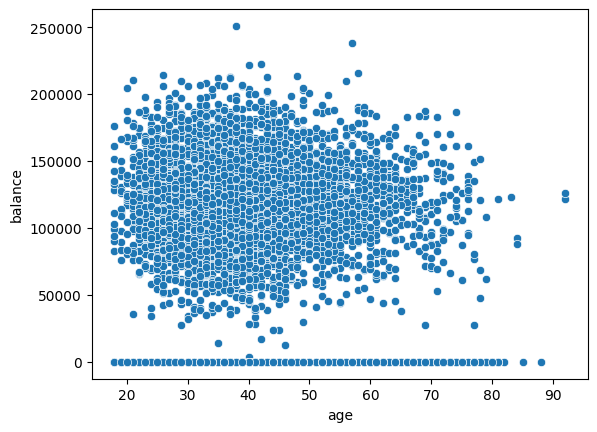

In [6]:
sns.scatterplot(x=ccdata['age'], y=ccdata['balance'])

<Axes: xlabel='churn', ylabel='estimated_salary'>

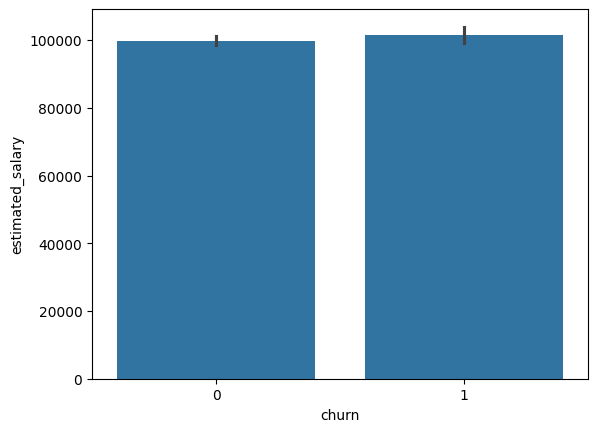

In [7]:
sns.barplot(y=ccdata['estimated_salary'], x=ccdata['churn'])

<Axes: xlabel='age', ylabel='Count'>

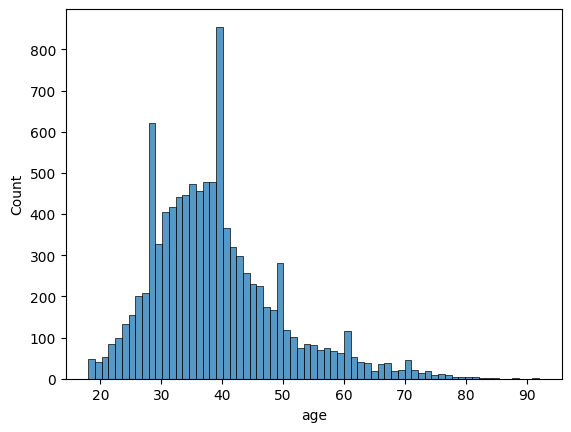

In [8]:
sns.histplot(ccdata['age'])

In [9]:
ccdata['gender'].value_counts()

,count
gender,
Male,5457
Female,4543


In [10]:
ccdata['churn'].value_counts()

,count
churn,
0,7963
1,2037


In [11]:
ccdata['country'].unique()

array(['France', 'Spain', 'Germany'], dtype=object)

In [12]:
#correlation code
def corr1(X,Y):
  if(len(X)==len(Y)):
    XYsum=sum((X-X.mean())*(Y-Y.mean()))
    Ysquare=sum((Y-Y.mean())**2)
    Xsquare=sum((X-X.mean())**2)
    return XYsum/((Xsquare*Ysquare)**0.5)


In [13]:
corr1((ccdata['estimated_salary']),(ccdata['balance']))

0.01279749634055569

In [14]:
correlationmap=ccdata.corr(numeric_only=True)

In [15]:
correlationmap

,customer_id,credit_score,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
customer_id,1.000000,0.005308,0.009497,-0.014883,-0.012419,0.016972,-0.014025,0.001665,0.015271,-0.006248
credit_score,0.005308,1.000000,-0.003965,0.000842,0.006268,0.012238,-0.005458,0.025651,-0.001384,-0.027094
age,0.009497,-0.003965,1.000000,-0.009997,0.028308,-0.030680,-0.011721,0.085472,-0.007201,0.285323
tenure,-0.014883,0.000842,-0.009997,1.000000,-0.012254,0.013444,0.022583,-0.028362,0.007784,-0.014001
balance,-0.012419,0.006268,0.028308,-0.012254,1.000000,-0.304180,-0.014858,-0.010084,0.012797,0.118533
products_number,0.016972,0.012238,-0.030680,0.013444,-0.304180,1.000000,0.003183,0.009612,0.014204,-0.047820
credit_card,-0.014025,-0.005458,-0.011721,0.022583,-0.014858,0.003183,1.000000,-0.011866,-0.009933,-0.007138
active_member,0.001665,0.025651,0.085472,-0.028362,-0.010084,0.009612,-0.011866,1.000000,-0.011421,-0.156128
estimated_salary,0.015271,-0.001384,-0.007201,0.007784,0.012797,0.014204,-0.009933,-0.011421,1.000000,0.012097
churn,-0.006248,-0.027094,0.285323,-0.014001,0.118533,-0.047820,-0.007138,-0.156128,0.012097,1.000000


ValueError: could not convert string to float: 'France'

In [16]:
countryencodedata=pd.get_dummies(ccdata['country'],dtype=int)

In [17]:
genderencodedata=pd.get_dummies(ccdata['gender'],dtype=int)

In [18]:
countryencodedata

,France,Germany,Spain
0,1,0,0
1,0,0,1
2,1,0,0
3,1,0,0
4,0,0,1
...,...,...,...
9995,1,0,0
9996,1,0,0
9997,1,0,0
9998,0,1,0


In [19]:
ccdata=pd.concat([ccdata,countryencodedata,genderencodedata],axis=1)

In [20]:
ccdata1=ccdata.drop(['country','gender'],axis=1)

In [21]:
ccdata1=ccdata1.drop(['customer_id'],axis=1)

In [22]:
ccdata1

,credit_score,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn,France,Germany,Spain,Female,Male
0,619,42,2,0.00,1,1,1,101348.88,1,1,0,0,1,0
1,608,41,1,83807.86,1,0,1,112542.58,0,0,0,1,1,0
2,502,42,8,159660.80,3,1,0,113931.57,1,1,0,0,1,0
3,699,39,1,0.00,2,0,0,93826.63,0,1,0,0,1,0
4,850,43,2,125510.82,1,1,1,79084.10,0,0,0,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771,39,5,0.00,2,1,0,96270.64,0,1,0,0,0,1
9996,516,35,10,57369.61,1,1,1,101699.77,0,1,0,0,0,1
9997,709,36,7,0.00,1,0,1,42085.58,1,1,0,0,1,0
9998,772,42,3,75075.31,2,1,0,92888.52,1,0,1,0,0,1


<Axes: xlabel='products_number', ylabel='count'>

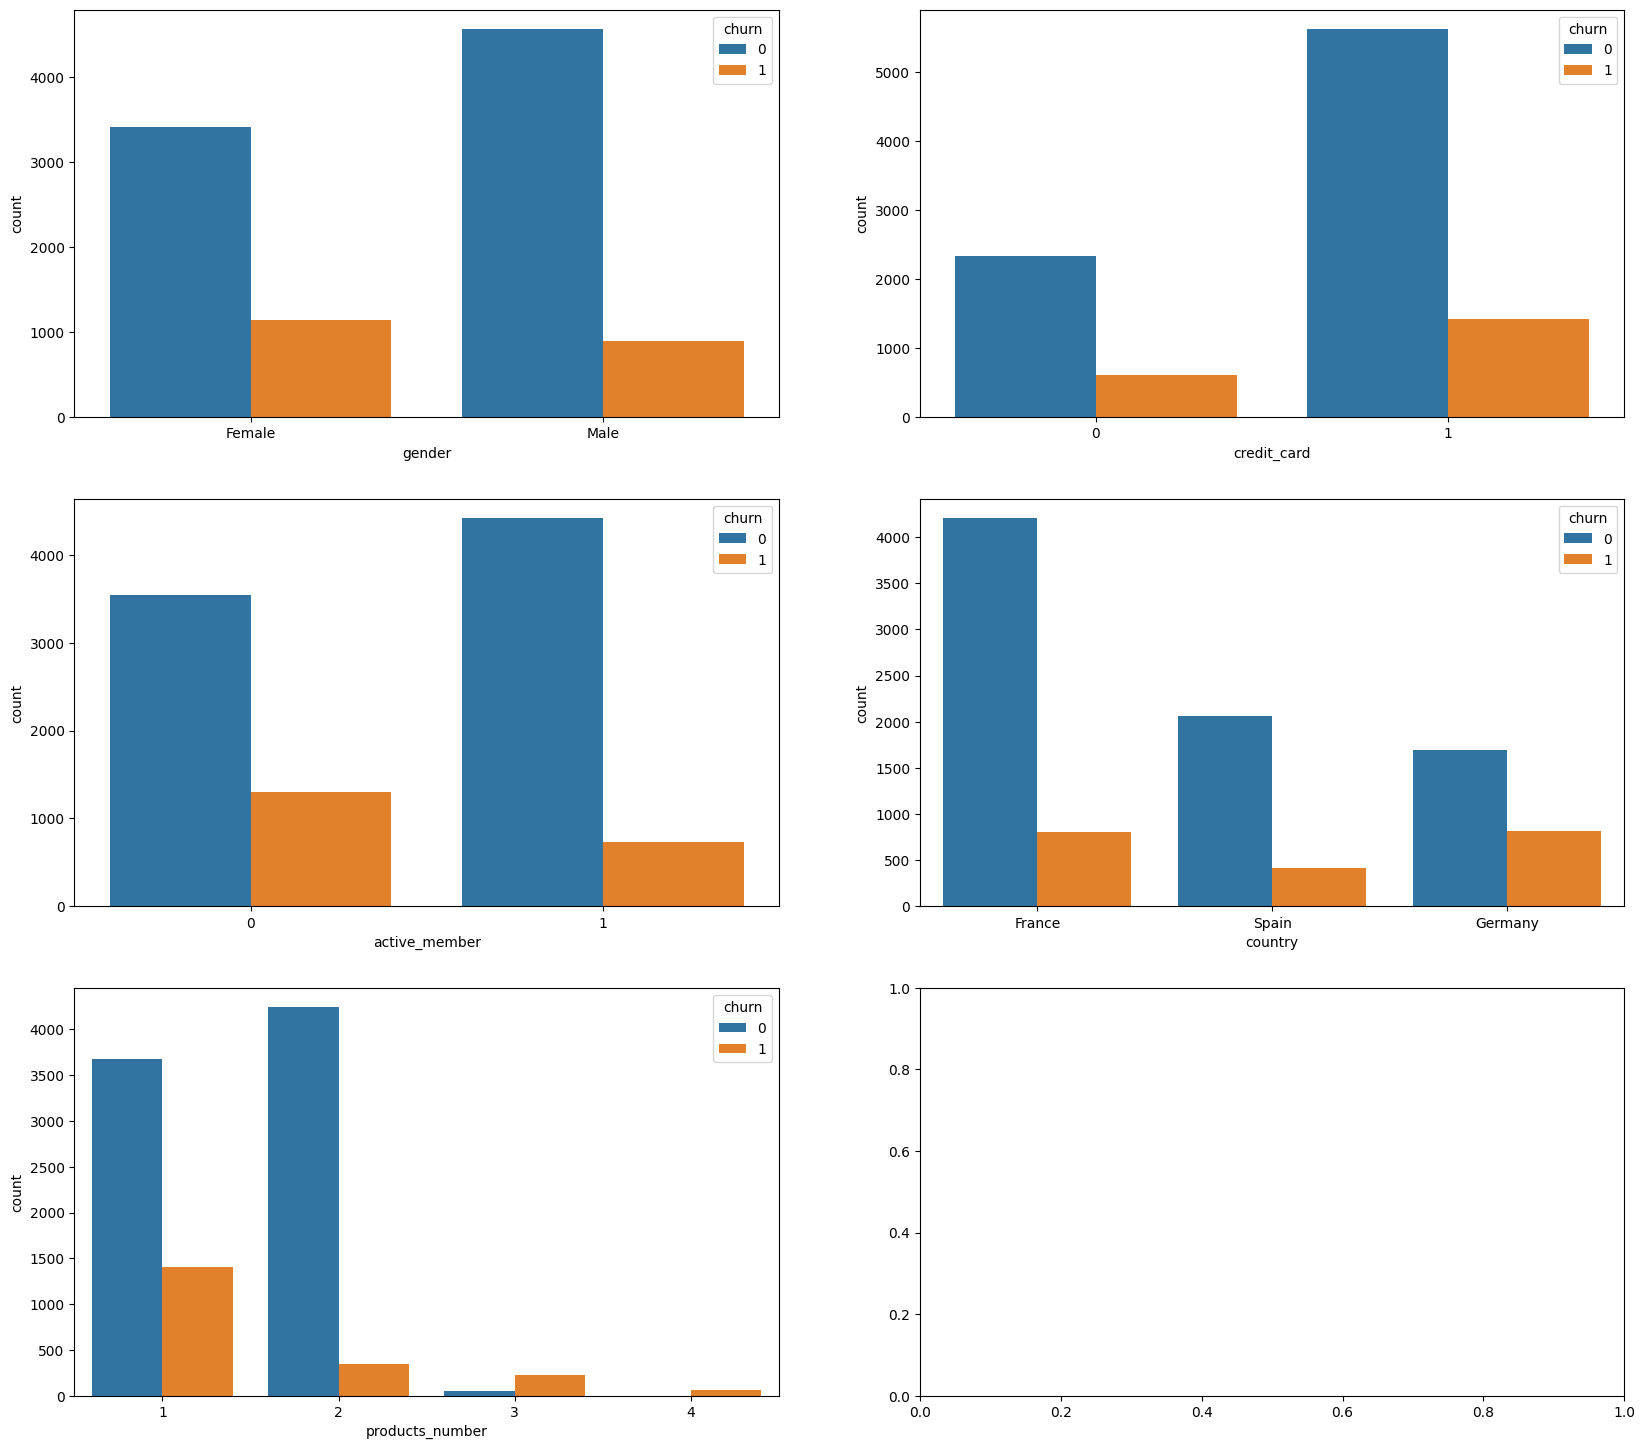

In [51]:
fig, axarr = plt.subplots(3, 2, figsize=(20, 18))
sns.countplot(x='gender', hue = 'churn',data = ccdata, ax=axarr[0][0])
sns.countplot(x='credit_card', hue = 'churn',data = ccdata, ax=axarr[0][1])
sns.countplot(x='active_member', hue = 'churn',data = ccdata, ax=axarr[1][0])
sns.countplot(x='country', hue = 'churn',data = ccdata, ax=axarr[1][1])
sns.countplot(x='products_number', hue='churn',data=ccdata,ax=axarr[2][0])

<Axes: xlabel='products_number', ylabel='Count'>

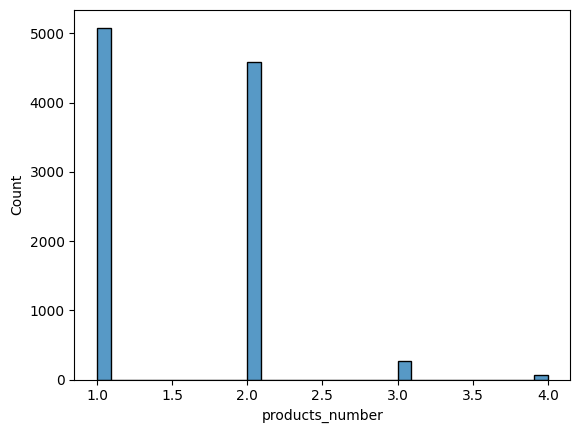

In [52]:
sns.histplot(ccdata['products_number'])

<Axes: xlabel='estimated_salary', ylabel='balance'>

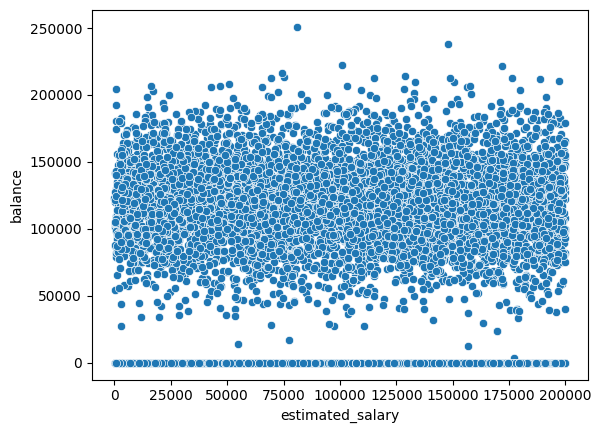

In [54]:
sns.scatterplot(x=ccdata['estimated_salary'], y=ccdata['balance'])

<Axes: xlabel='churn', ylabel='estimated_salary'>

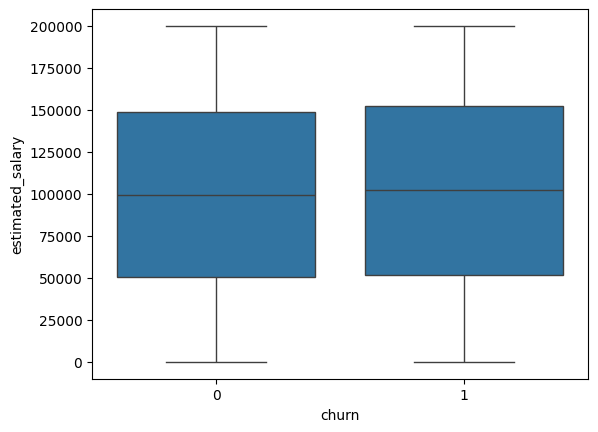

In [55]:
sns.boxplot(x=ccdata['churn'], y=ccdata['estimated_salary'])

<Axes: xlabel='churn', ylabel='balance'>

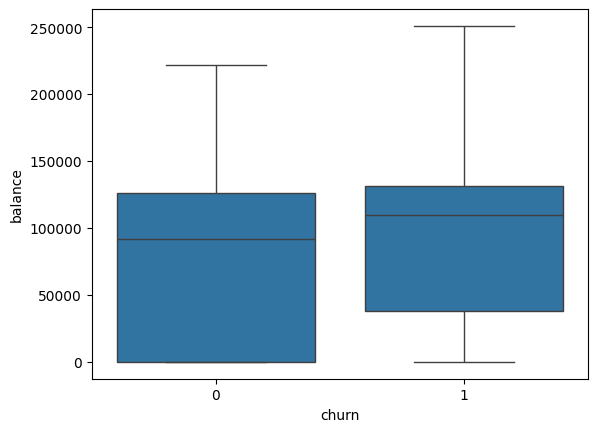

In [56]:
sns.boxplot(x=ccdata['churn'], y=ccdata['balance'])

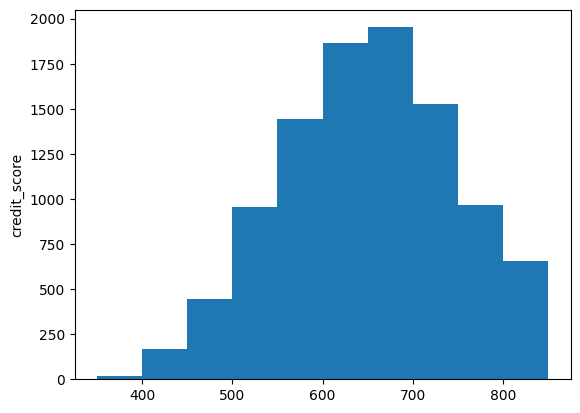

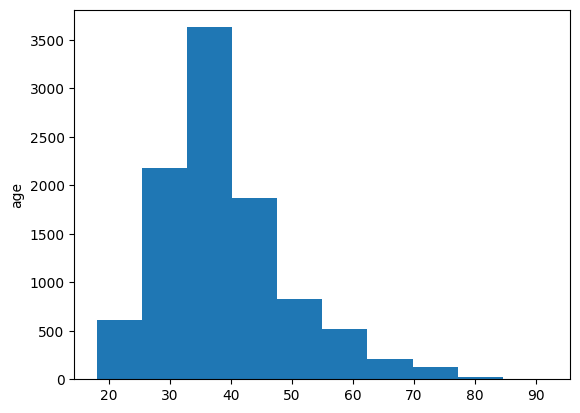

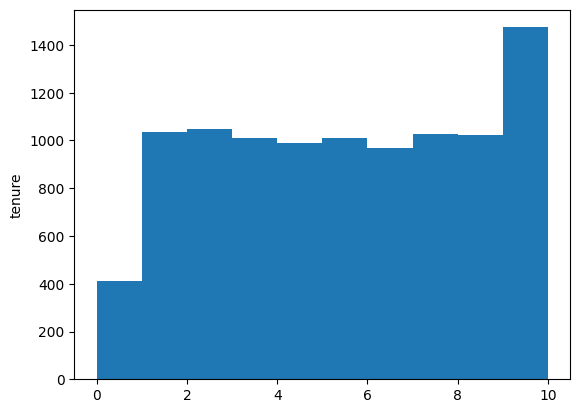

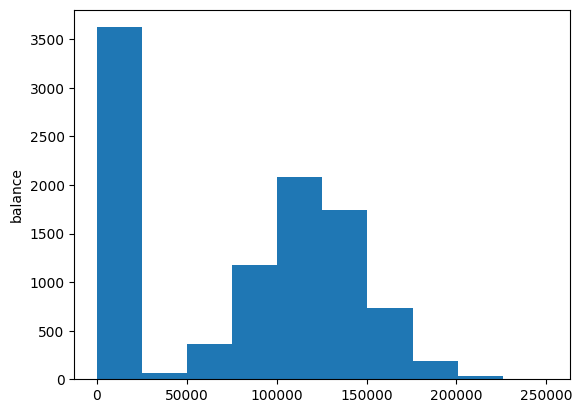

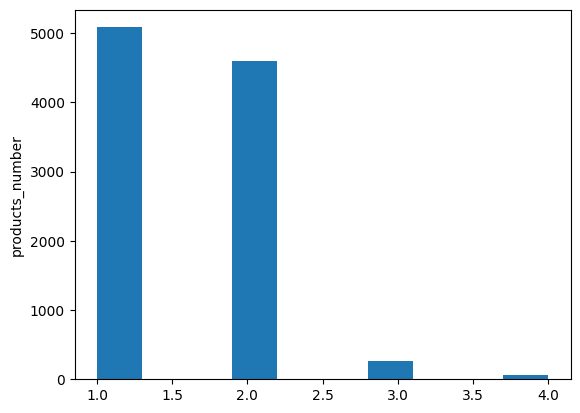

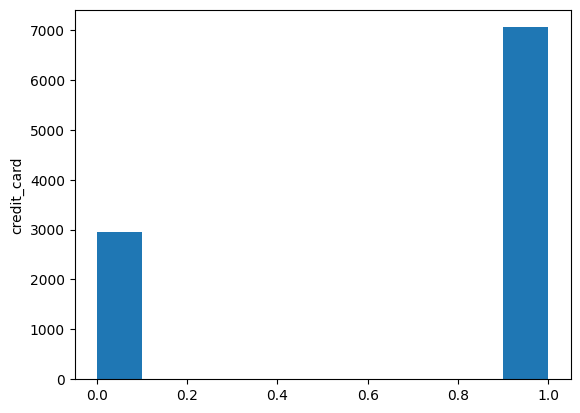

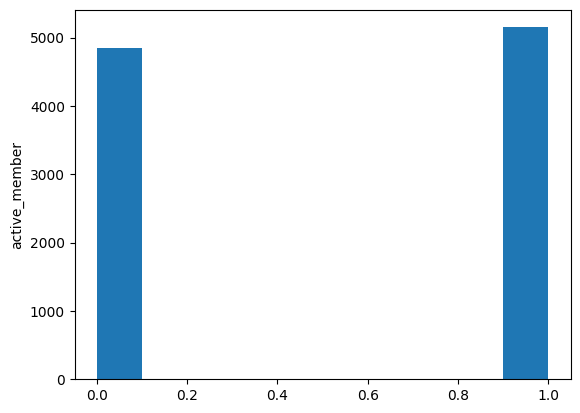

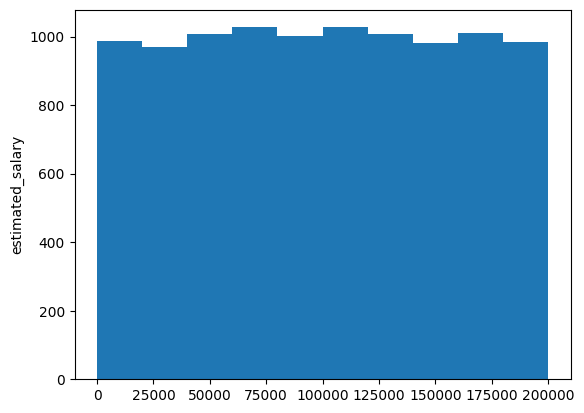

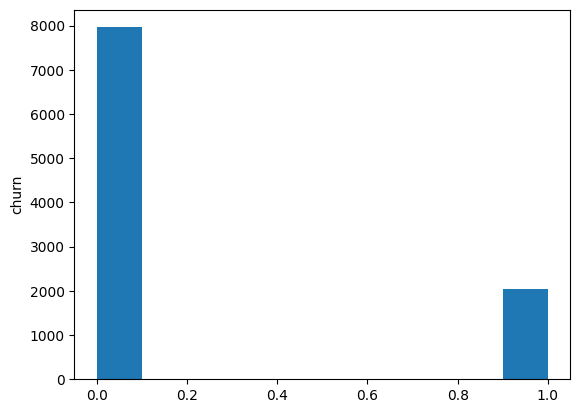

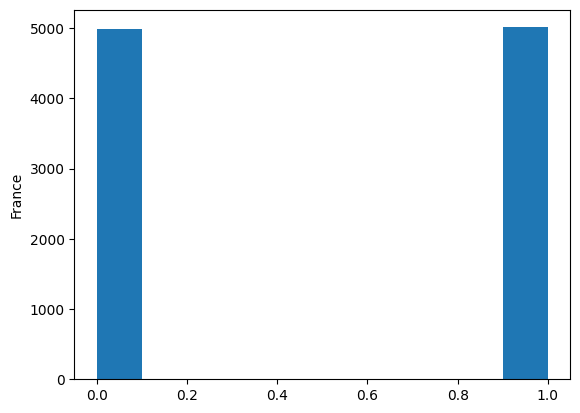

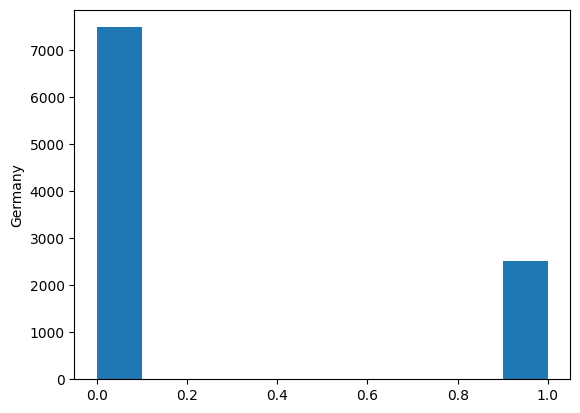

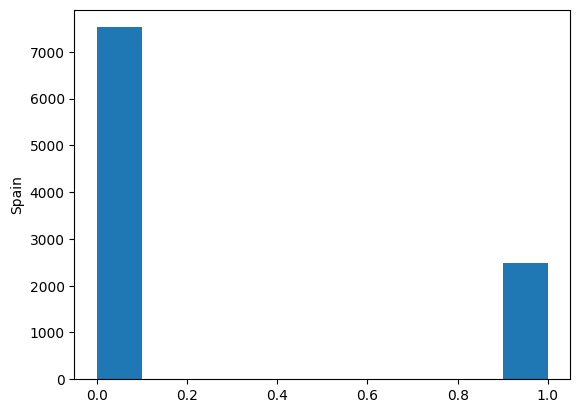

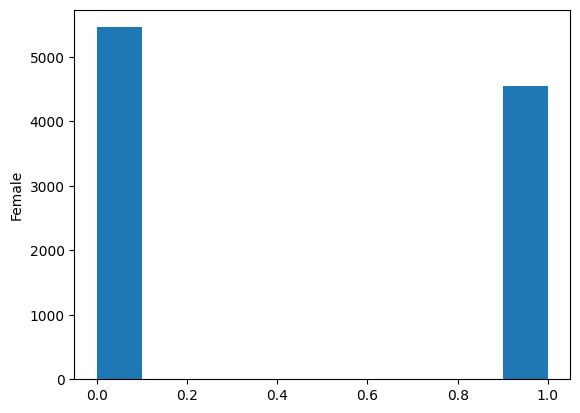

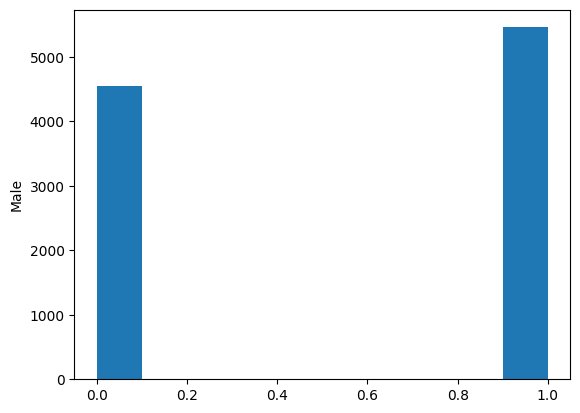

In [23]:
for col in ccdata1.columns:
  plt.hist(ccdata[col])
  plt.ylabel(col)
  plt.show()


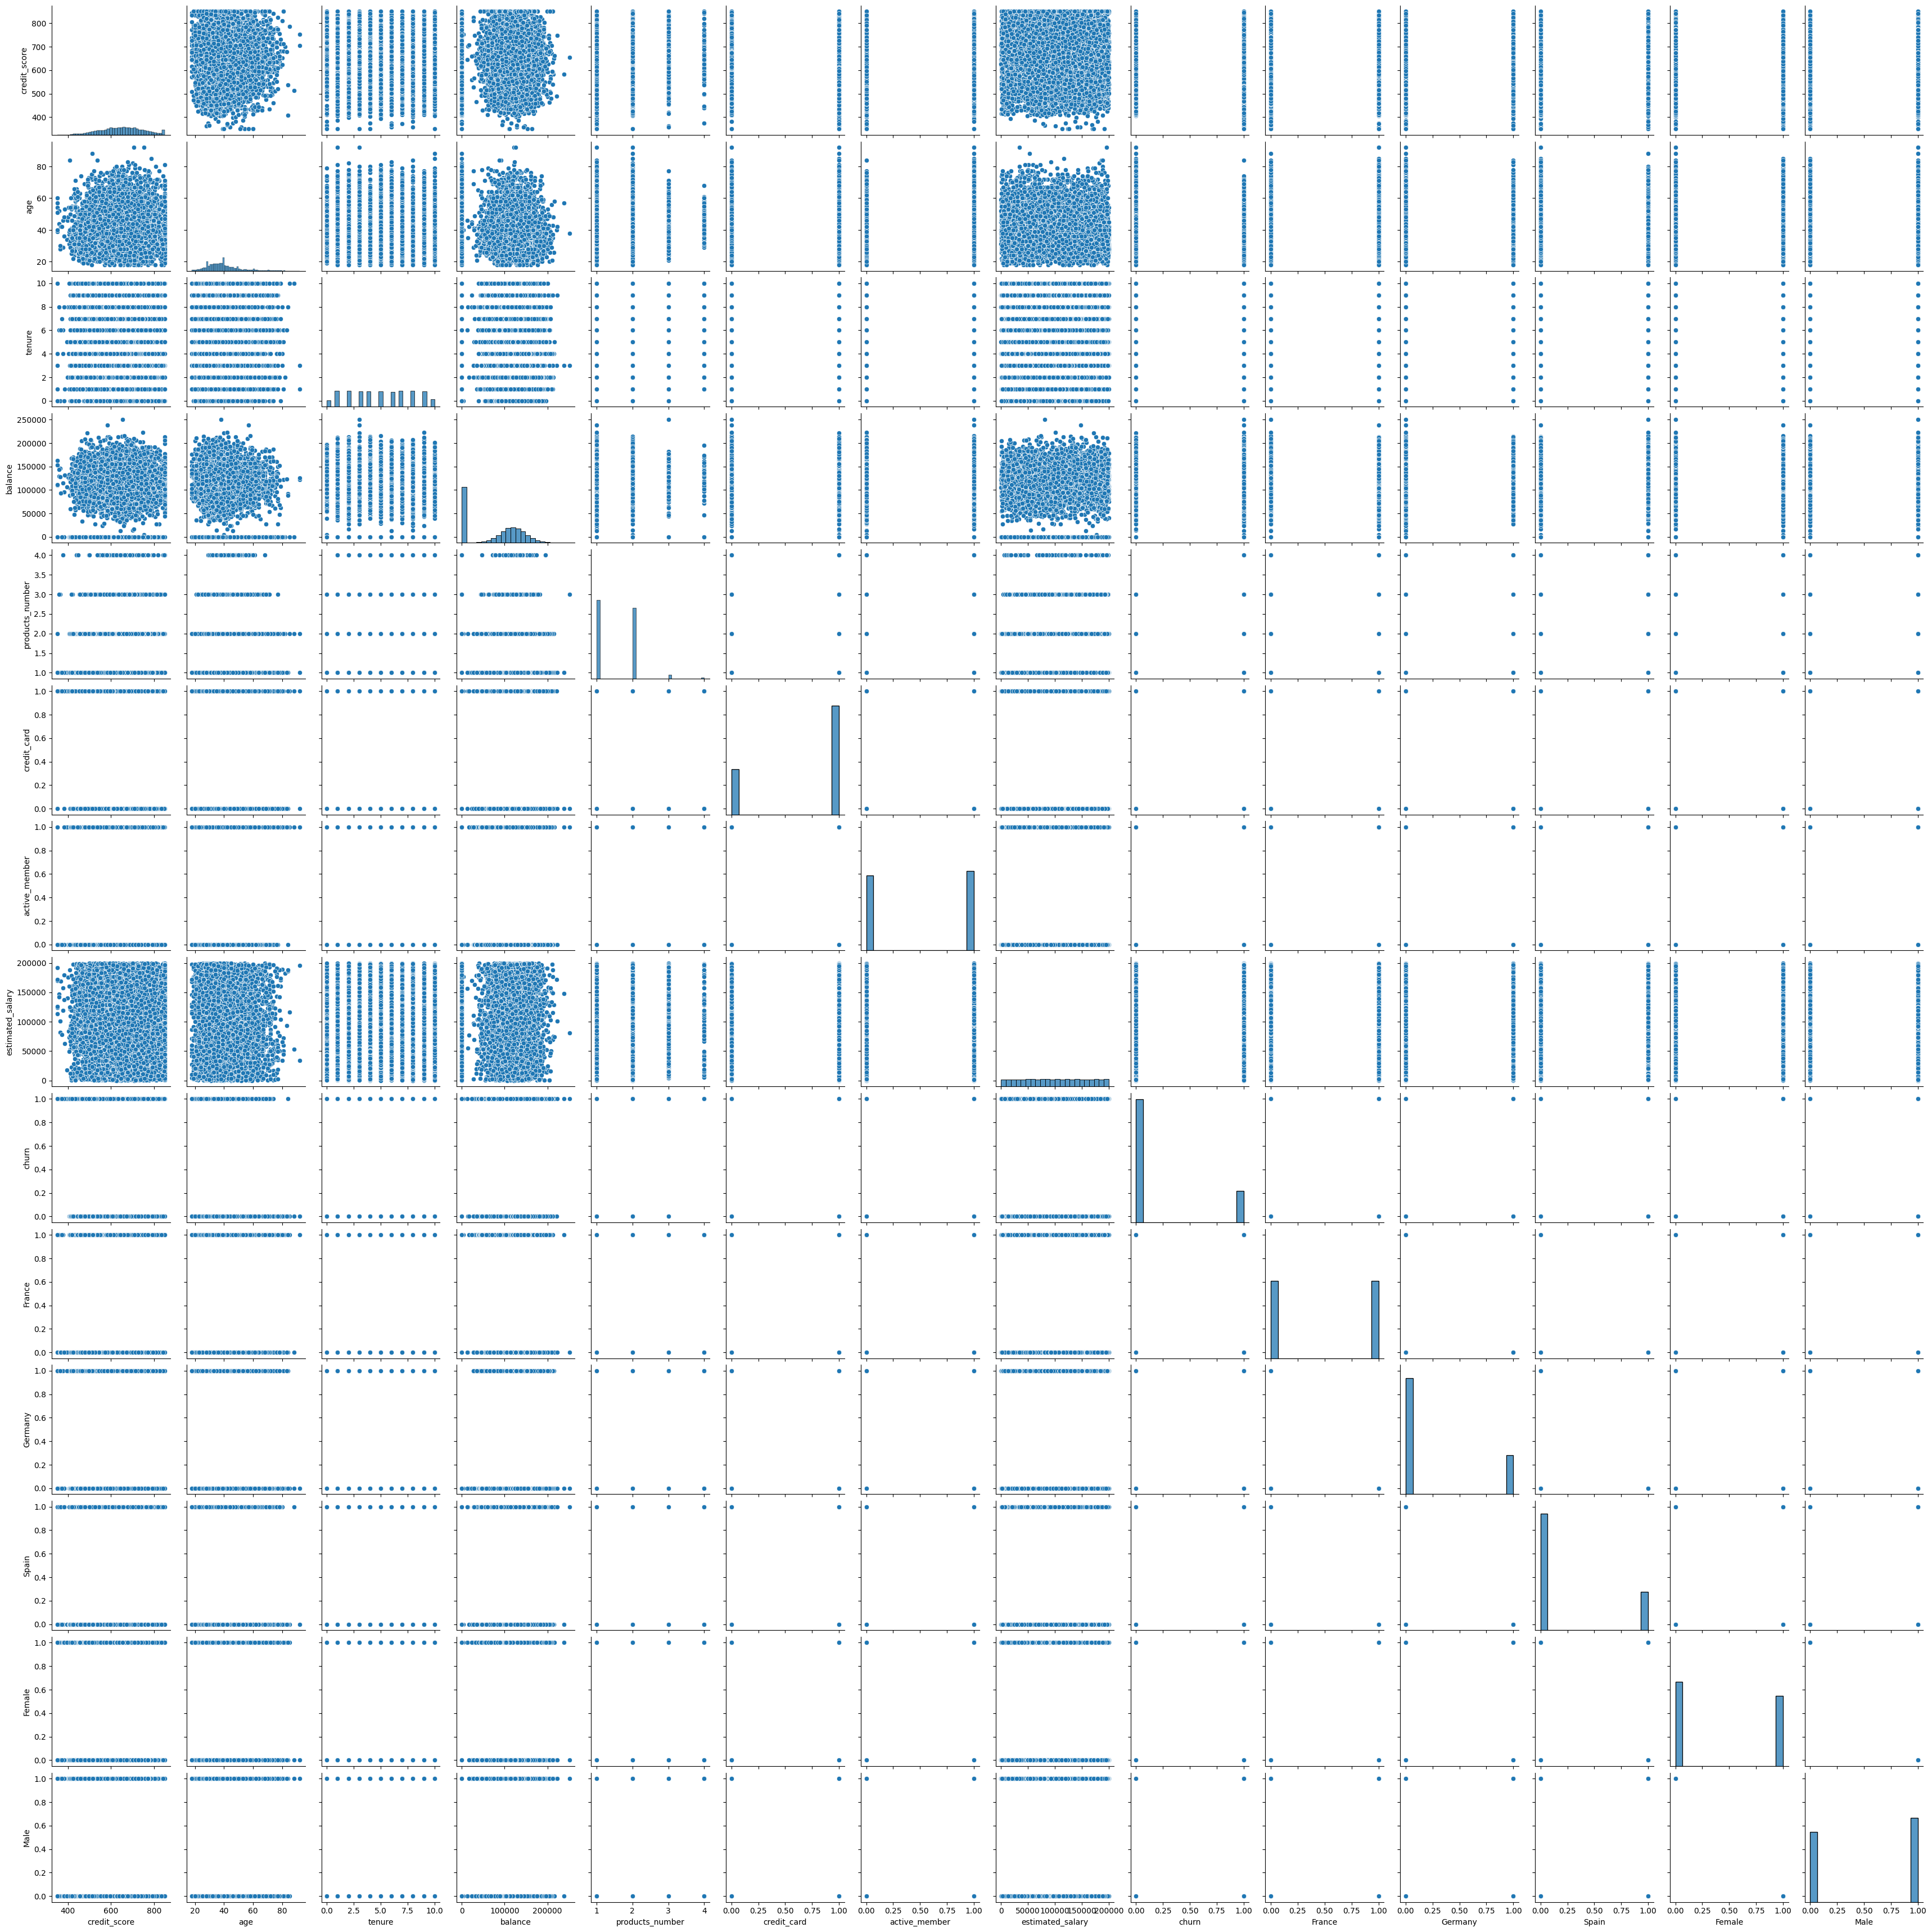

In [24]:
sns.pairplot(ccdata1)

<Axes: >

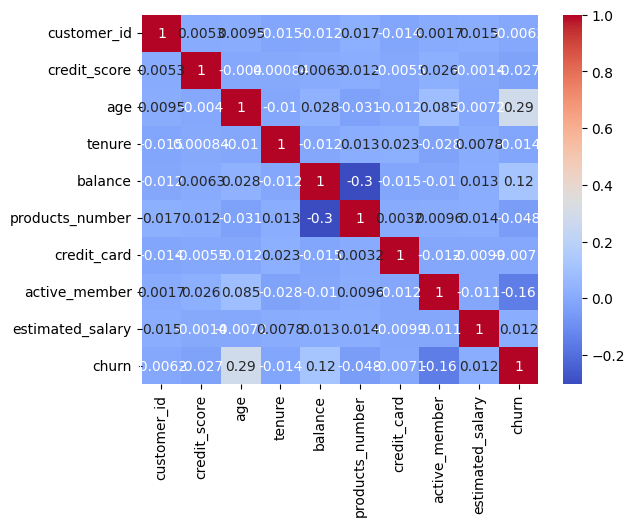

In [61]:
sns.heatmap(correlationmap, annot=True, cmap='coolwarm')

In [25]:
from sklearn import preprocessing

In [26]:
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

In [27]:
from sklearn.metrics import classification_report

In [28]:
X1=ccdata1.drop(['churn'],axis=1)
Y1=ccdata1['churn']


In [29]:
Y1

,churn
0,1
1,0
2,1
3,0
4,0
...,...
9995,0
9996,0
9997,1
9998,1


In [30]:
X_train,X_test,y_train,y_test=train_test_split(X1,Y1,test_size=0.2,random_state=42)

In [31]:
logisticmodel=LogisticRegression()
logisticmodel.fit(X_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [32]:
predy=logisticmodel.predict(X_test)
print(classification_report(y_test,predy))

              precision    recall  f1-score   support

           0       0.81      0.98      0.89      1607
           1       0.45      0.08      0.14       393

    accuracy                           0.80      2000
   macro avg       0.63      0.53      0.51      2000
weighted avg       0.74      0.80      0.74      2000



In [33]:
min_max_scaler = preprocessing.MinMaxScaler()
X_train_minmax = min_max_scaler.fit_transform(X_train)
X_test_minmax = min_max_scaler.transform(X_test)

In [34]:
from sklearn.preprocessing import MinMaxScaler

In [35]:
pipe = make_pipeline(MinMaxScaler(),StandardScaler(), LogisticRegression())
pipe.fit(X_train, y_train)

Pipeline(steps=[('minmaxscaler', MinMaxScaler()),
                ('standardscaler', StandardScaler()),
                ('logisticregression', LogisticRegression())])

In [36]:
y_pred=pipe.predict(X_test)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.83      0.96      0.89      1607
           1       0.55      0.20      0.29       393

    accuracy                           0.81      2000
   macro avg       0.69      0.58      0.59      2000
weighted avg       0.78      0.81      0.77      2000



In [37]:
from sklearn.linear_model import LogisticRegressionCV

In [38]:
pipe1 = make_pipeline(MinMaxScaler(),StandardScaler(), LogisticRegressionCV())
pipe1.fit(X_train, y_train)

Pipeline(steps=[('minmaxscaler', MinMaxScaler()),
                ('standardscaler', StandardScaler()),
                ('logisticregressioncv', LogisticRegressionCV())])

In [39]:
y_pred=pipe1.predict(X_test)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.83      0.96      0.89      1607
           1       0.55      0.20      0.29       393

    accuracy                           0.81      2000
   macro avg       0.69      0.58      0.59      2000
weighted avg       0.78      0.81      0.77      2000



In [40]:
weights = {0: 1, 1: 4}  # Weight 10 for class 1 (minority class)
pipe1 = make_pipeline(MinMaxScaler(),StandardScaler(), LogisticRegressionCV(random_state=42, class_weight=weights))
pipe1.fit(X_train, y_train)
y_pred=pipe1.predict(X_test)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.91      0.71      0.80      1607
           1       0.38      0.73      0.50       393

    accuracy                           0.71      2000
   macro avg       0.65      0.72      0.65      2000
weighted avg       0.81      0.71      0.74      2000



In [41]:
# Create a BalancedBaggingClassifier
from imblearn.ensemble import BalancedBaggingClassifier


In [42]:
balanced_bagging_classifier = BalancedBaggingClassifier(logisticmodel,
                                                        sampling_strategy='auto',  # You can adjust this parameter
                                                        replacement=False,  # Whether to sample with or without replacement
                                                        random_state=42)

In [43]:
pipe1 = make_pipeline(MinMaxScaler(),StandardScaler(), balanced_bagging_classifier)
pipe1.fit(X_train, y_train)

Pipeline(steps=[('minmaxscaler', MinMaxScaler()),
                ('standardscaler', StandardScaler()),
                ('balancedbaggingclassifier',
                 BalancedBaggingClassifier(estimator=LogisticRegression(),
                                           random_state=42))])

In [44]:
y_pred=pipe1.predict(X_test)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.91      0.72      0.80      1607
           1       0.38      0.70      0.49       393

    accuracy                           0.72      2000
   macro avg       0.64      0.71      0.65      2000
weighted avg       0.80      0.72      0.74      2000



In [45]:
param_grid = [
    {'penalty':['l1','l2','elasticnet','none'],
    'C' : np.logspace(-4,4,20),
    'solver': ['lbfgs','newton-cg','liblinear','sag','saga'],
    'max_iter'  : [100,1000,2500,5000]
}
]

In [47]:
# from sklearn.model_selection import GridSearchCV

# # Base model
# logistic = LogisticRegression(
#     random_state=42,
#     class_weight=weights,
#     max_iter=1000
# )



# # Pipeline
# pipe = make_pipeline(
#     StandardScaler(),
#     GridSearchCV(
#         logistic,
#         param_grid=param_grid,
#         cv=3,
#         scoring='f1',
#         n_jobs=-1,
#         verbose=1
#     )
# )

# # Fit
# pipe.fit(X_train, y_train)

# # Predict
# y_pred = pipe.predict(X_test)

# print(classification_report(y_test, y_pred))


Fitting 3 folds for each of 1600 candidates, totalling 4800 fits


KeyboardInterrupt: 